In [1]:
import pandas as pd

df = pd.read_excel("2018.xlsx")

print(df.describe())

print("Min SST:", df['sst'].min())

print("Max SST:", df['sst'].max())

print(df.columns.tolist())

print(df.head())

         longitude      latitude          sst  Unnamed: 4   Unnamed: 5  \
count  2920.000000  2.920000e+03  2920.000000         0.0   365.000000   
mean     72.360001  1.033000e+01    29.055270         NaN  1458.000000   
std       0.000000  1.776661e-15     0.792068         NaN   844.085304   
min      72.360001  1.033000e+01    27.260160         NaN     2.000000   
25%      72.360001  1.033000e+01    28.403220         NaN   730.000000   
50%      72.360001  1.033000e+01    29.093130         NaN  1458.000000   
75%      72.360001  1.033000e+01    29.536800         NaN  2186.000000   
max      72.360001  1.033000e+01    31.255520         NaN  2914.000000   

       Unnamed: 6  Unnamed: 7  
count    6.000000  365.000000  
mean    28.306112   29.055270  
std      0.144184    0.793019  
min     28.017970   27.260160  
25%     28.329950   28.403220  
50%     28.348790   29.093130  
75%     28.384880   29.536800  
max     28.400540   31.255520  
Min SST: 27.26016000000004
Max SST: 31.255520

In [2]:
df = df[[
    'time',
    'sst'
]]

df['time'] = pd.to_datetime(df['time'])

df['month'] = df['time'].dt.month

df['day'] = df['time'].dt.day

df['hour'] = df['time'].dt.hour

df['dayofyear'] = df['time'].dt.dayofyear



MEMORY SIZE: 0

TRAINING TASK 2018

TRAINING TASK 2019

TRAINING TASK 2020

TRAINING TASK 2021

TRAINING TASK 2022

RESULTS
Average RMSE : 0.0636
Average MAE  : 0.0387
Average R²   : 0.9719
Total Time   : 0.6975


MEMORY SIZE: 50

TRAINING TASK 2018

TRAINING TASK 2019

TRAINING TASK 2020

TRAINING TASK 2021

TRAINING TASK 2022

RESULTS
Average RMSE : 0.0644
Average MAE  : 0.041
Average R²   : 0.9545
Total Time   : 0.4926


MEMORY SIZE: 100

TRAINING TASK 2018

TRAINING TASK 2019

TRAINING TASK 2020

TRAINING TASK 2021

TRAINING TASK 2022

RESULTS
Average RMSE : 0.0635
Average MAE  : 0.04
Average R²   : 0.966
Total Time   : 0.415


MEMORY SIZE: 250

TRAINING TASK 2018

TRAINING TASK 2019

TRAINING TASK 2020

TRAINING TASK 2021

TRAINING TASK 2022

RESULTS
Average RMSE : 0.0659
Average MAE  : 0.0399
Average R²   : 0.971
Total Time   : 0.4138


MEMORY SIZE: 500

TRAINING TASK 2018

TRAINING TASK 2019

TRAINING TASK 2020

TRAINING TASK 2021

TRAINING TASK 2022

RESULTS
Average RMSE : 0.

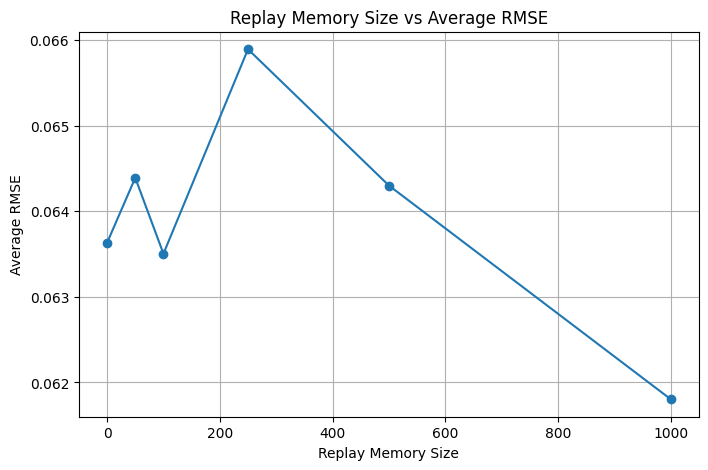

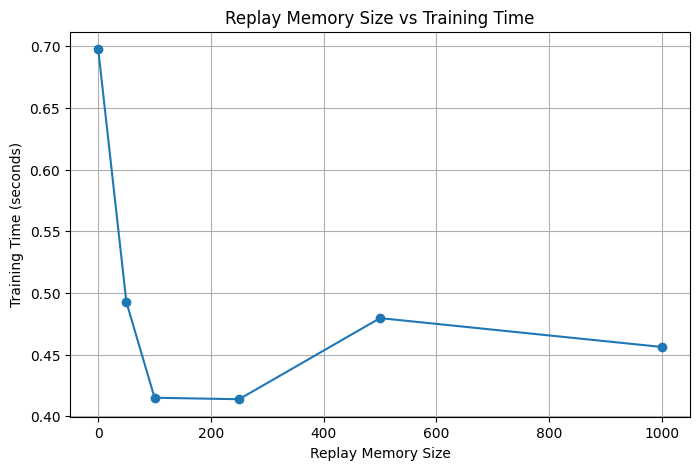

In [ ]:
import pandas as pd
import numpy as np
import time

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# ======================================================
# LOAD DATA
# ======================================================

df2018 = pd.read_excel("../data/2018.xlsx")
df2019 = pd.read_excel("../data/2019.xlsx")
df2020 = pd.read_excel("../data/2020.xlsx")
df2021 = pd.read_excel("../data/2021.xlsx")
df2022 = pd.read_excel("../data/2022.xlsx")

# ======================================================
# PREPROCESSING
# ======================================================

def preprocess(df):

    df = df[['time','sst']].copy()

    df['time'] = pd.to_datetime(df['time'])

    df['month'] = df['time'].dt.month
    df['day'] = df['time'].dt.day
    df['hour'] = df['time'].dt.hour
    df['dayofyear'] = df['time'].dt.dayofyear

    # Lag Features

    df['sst_lag1'] = df['sst'].shift(1)

    df['sst_lag8'] = df['sst'].shift(8)

    df['sst_lag24'] = df['sst'].shift(24)

    df.dropna(inplace=True)

    return df

df2018 = preprocess(df2018)
df2019 = preprocess(df2019)
df2020 = preprocess(df2020)
df2021 = preprocess(df2021)
df2022 = preprocess(df2022)

# ======================================================
# TASKS (YEAR-WISE CONTINUAL LEARNING)
# ======================================================

features = [

    'month',
    'day',
    'hour',
    'dayofyear',

    'sst_lag1',
    'sst_lag8',
    'sst_lag24'

]

tasks = [
    df2018,
    df2019,
    df2020,
    df2021,
    df2022
]



target = 'sst'

# ======================================================
# MODEL
# ======================================================

cl_model = RandomForestRegressor(
    n_estimators=50,
    warm_start=True,
    random_state=42,
    n_jobs=-1
)

# ======================================================
# REPLAY MEMORY
# ======================================================

memory_X = []
memory_y = []

memory_size = 50

# ======================================================
# METRICS STORAGE
# ======================================================

rmses = []
maes = []
r2s = []

total_time = 0

memory_values = [
    0,
    50,
    100,
    250,
    500,
    1000
]

avg_rmse_list = []
avg_time_list = []

# ======================================================
# CONTINUAL LEARNING LOOP
# ======================================================
for memory_size in memory_values:

    print("\n")
    print("="*50)
    print("MEMORY SIZE:", memory_size)
    print("="*50)

    memory_X = []
    memory_y = []

    rmses = []
    maes = []
    r2s = []

    total_time = 0

    cl_model = RandomForestRegressor(
        n_estimators=50,
        warm_start=True,
        random_state=42,
        n_jobs=-1
    )

    for i, task in enumerate(tasks):

        year = 2018 + i

        print("\n===================================")
        print(f"TRAINING TASK {year}")
        print("===================================")

        X_task = task[features]
        y_task = task[target]

        # ==================================
        # REPLAY
        # ==================================

        if len(memory_X) > 0:

            replay_X = pd.DataFrame(
                memory_X,
                columns=features
            )

            replay_y = pd.Series(
                memory_y
            )

            X_task = pd.concat(
                [X_task, replay_X],
                ignore_index=True
            )

            y_task = pd.concat(
                [y_task, replay_y],
                ignore_index=True
            )

        split = int(len(X_task) * 0.8)

        X_train = X_task.iloc[:split]
        X_test = X_task.iloc[split:]

        y_train = y_task.iloc[:split]
        y_test = y_task.iloc[split:]

        start = time.time()

        cl_model.n_estimators += 25

        cl_model.fit(
            X_train,
            y_train
        )

        end = time.time()

        train_time = end - start

        total_time += train_time

        # ==================================
        # RANDOM REPLAY MEMORY
        # ==================================

        sample_idx = np.random.choice(
            len(X_train),
            size=min(100, len(X_train)),
            replace=False
        )

        memory_X.extend(
            X_train.iloc[sample_idx]
            .values
            .tolist()
        )

        memory_y.extend(
            y_train.iloc[sample_idx]
            .tolist()
        )

        memory_X = memory_X[-memory_size:]
        memory_y = memory_y[-memory_size:]

        predictions = cl_model.predict(
            X_test
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        mae = mean_absolute_error(
            y_test,
            predictions
        )

        r2 = r2_score(
            y_test,
            predictions
        )

        rmses.append(rmse)
        maes.append(mae)
        r2s.append(r2)

    avg_rmse = np.mean(rmses)

    avg_rmse_list.append(
        avg_rmse
    )

    avg_time_list.append(
        total_time
    )

    print("\nRESULTS")
    print("Average RMSE :", round(avg_rmse, 4))
    print("Average MAE  :", round(np.mean(maes), 4))
    print("Average R²   :", round(np.mean(r2s), 4))
    print("Total Time   :", round(total_time, 4))


import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    memory_values,
    avg_rmse_list,
    marker='o'
)

plt.xlabel(
    "Replay Memory Size"
)

plt.ylabel(
    "Average RMSE"
)

plt.title(
    "Replay Memory Size vs Average RMSE"
)

plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    memory_values,
    avg_time_list,
    marker='o'
)

plt.xlabel(
    "Replay Memory Size"
)

plt.ylabel(
    "Training Time (seconds)"
)

plt.title(
    "Replay Memory Size vs Training Time"
)

plt.grid(True)

plt.show()

In [4]:
print(df2018.columns.tolist())

['time', 'sst', 'month', 'day', 'hour', 'dayofyear', 'sst_lag1', 'sst_lag8', 'sst_lag24']


In [5]:
print(features)

print(df2018[features].head())

print(
    df2018[['sst','sst_lag1','sst_lag8','sst_lag24']]
    .corr()
)

['month', 'day', 'hour', 'dayofyear', 'sst_lag1', 'sst_lag8', 'sst_lag24']
    month  day  hour  dayofyear  sst_lag1  sst_lag8  sst_lag24
24      1    4     0          4  28.01797  28.01797   28.40054
25      1    4     3          4  28.33196  28.01797   28.40054
26      1    4     6          4  28.33196  28.01797   28.40054
27      1    4     9          4  28.33196  28.01797   28.40054
28      1    4    12          4  28.33196  28.01797   28.40054
                sst  sst_lag1  sst_lag8  sst_lag24
sst        1.000000  0.997123  0.977034   0.952867
sst_lag1   0.997123  1.000000  0.979909   0.954758
sst_lag8   0.977034  0.979909  1.000000   0.967969
sst_lag24  0.952867  0.954758  0.967969   1.000000


In [6]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": cl_model.feature_importances_
})

print(
    importance.sort_values(
        by="Importance",
        ascending=False
    )
)

     Feature  Importance
4   sst_lag1    0.994394
6  sst_lag24    0.001532
3  dayofyear    0.001187
1        day    0.001020
2       hour    0.000908
5   sst_lag8    0.000847
0      month    0.000111



TRAINING TASK 2018


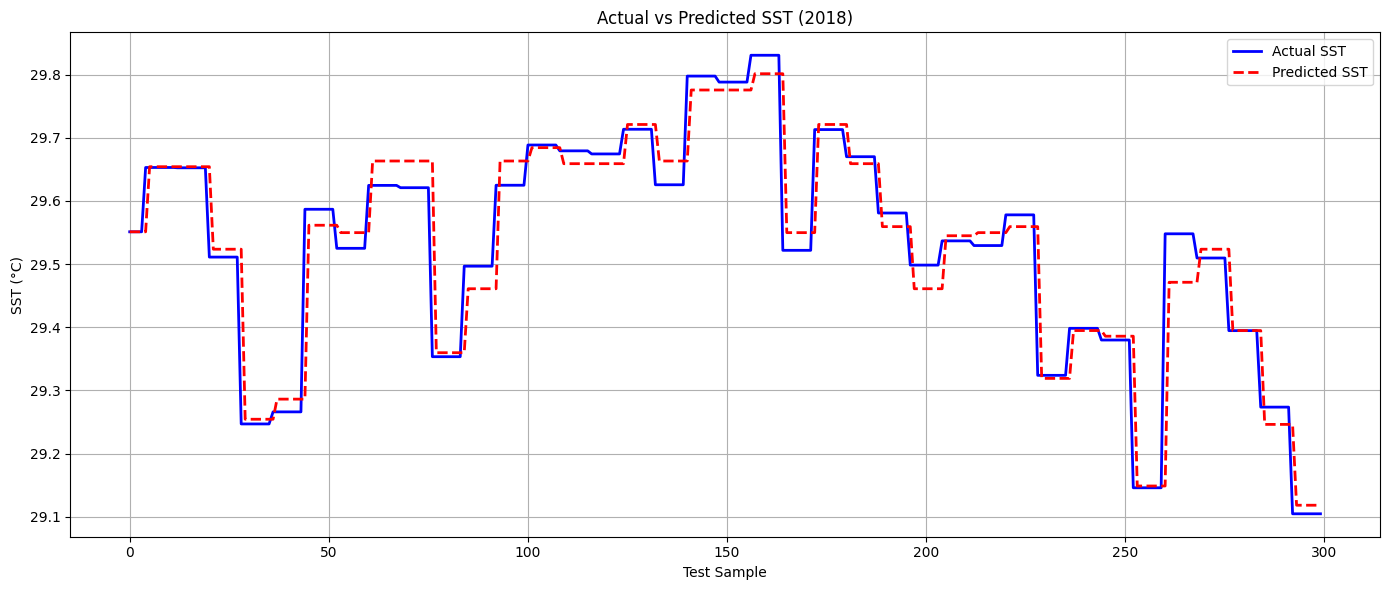

RMSE : 0.0519
MAE  : 0.0277
R²   : 0.9515
Training Time : 0.1554 seconds

TRAINING TASK 2019


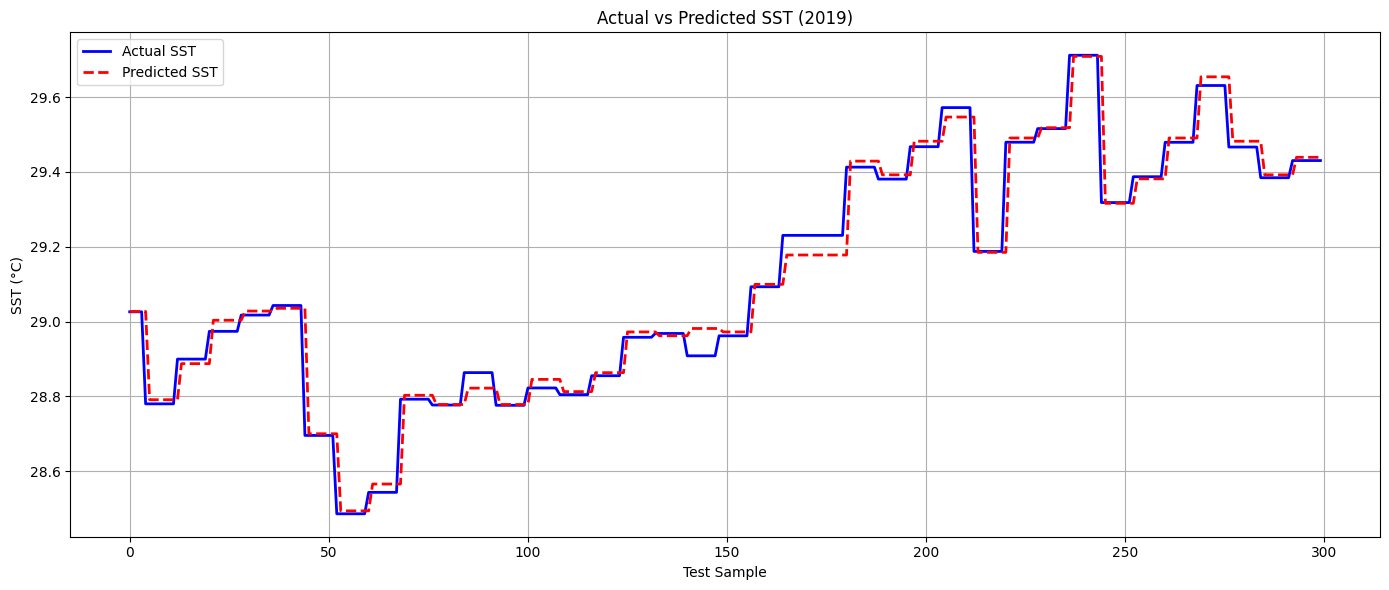

RMSE : 0.0551
MAE  : 0.0267
R²   : 0.9758
Training Time : 0.0493 seconds

TRAINING TASK 2020


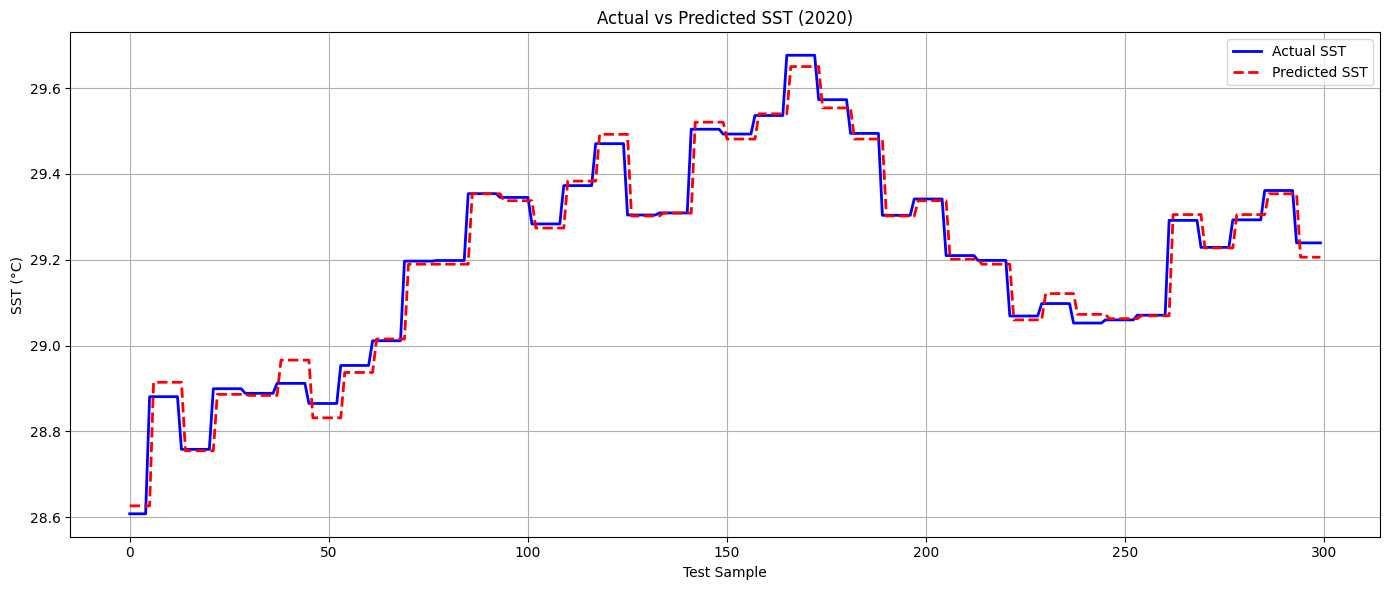

RMSE : 0.0475
MAE  : 0.0227
R²   : 0.9703
Training Time : 0.0556 seconds

TRAINING TASK 2021


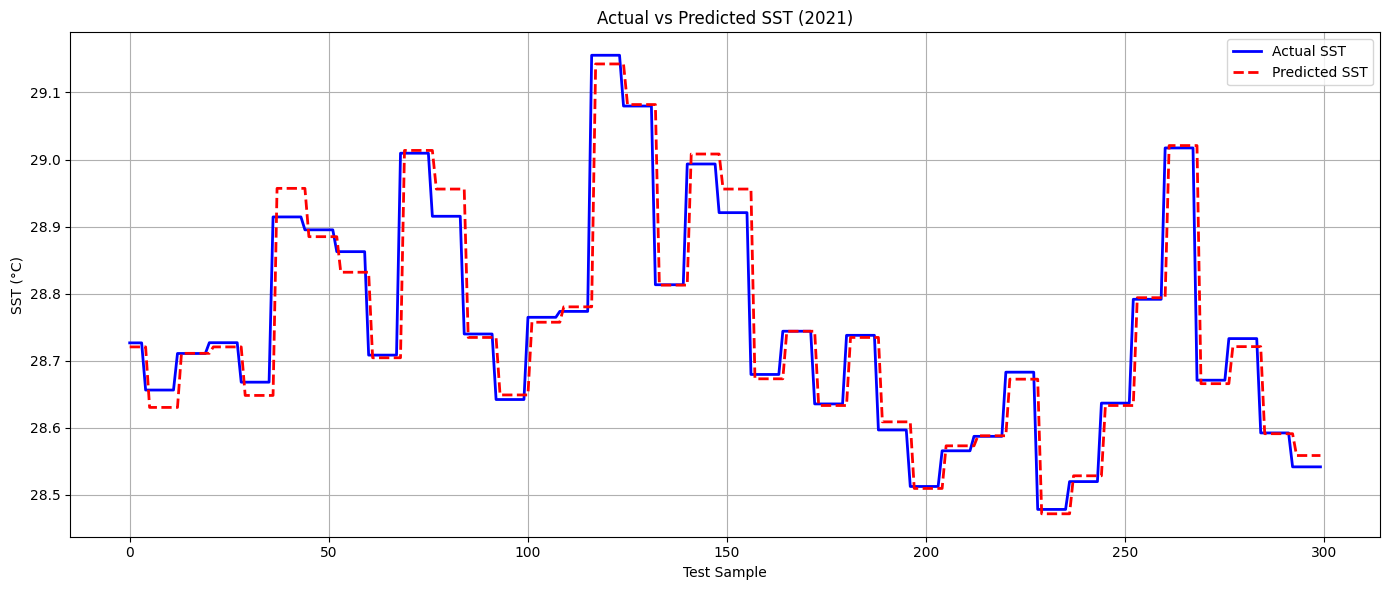

RMSE : 0.0519
MAE  : 0.0224
R²   : 0.9719
Training Time : 0.0508 seconds

TRAINING TASK 2022


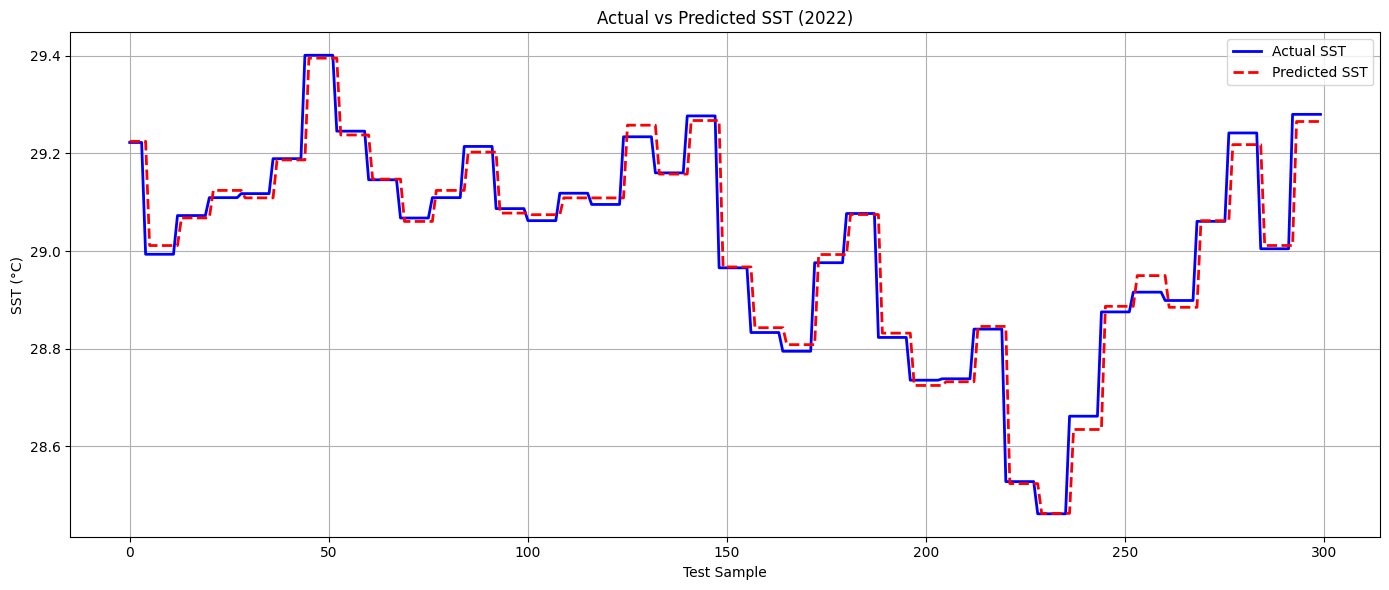

RMSE : 0.0461
MAE  : 0.0218
R²   : 0.9807
Training Time : 0.0769 seconds

FINAL RESULTS
Average RMSE : 0.0505
Average R² : 0.97
Total Training Time : 0.388 seconds
Average Time Per Task : 0.0776 seconds


In [14]:
import pandas as pd
import numpy as np
import time

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =====================================================
# LOAD DATA
# =====================================================

df2018 = pd.read_excel("2018.xlsx")
df2019 = pd.read_excel("2019.xlsx")
df2020 = pd.read_excel("2020.xlsx")
df2021 = pd.read_excel("2021.xlsx")
df2022 = pd.read_excel("2022.xlsx")

# =====================================================
# PREPROCESS
# =====================================================

def preprocess(df):

    df = df[['time','sst']].copy()

    df['time'] = pd.to_datetime(
        df['time']
    )

    df['month'] = df['time'].dt.month

    df['day'] = df['time'].dt.day

    df['hour'] = df['time'].dt.hour

    df['dayofyear'] = (
        df['time']
        .dt.dayofyear
    )

    # =========================
    # LAG FEATURES
    # =========================

    df['sst_lag1'] = (
        df['sst']
        .shift(1)
    )

    df['sst_lag8'] = (
        df['sst']
        .shift(8)
    )

    df['sst_lag24'] = (
        df['sst']
        .shift(24)
    )

    df.dropna(inplace=True)

    return df

# =====================================================
# PROCESS ALL YEARS
# =====================================================

df2018 = preprocess(df2018)
df2019 = preprocess(df2019)
df2020 = preprocess(df2020)
df2021 = preprocess(df2021)
df2022 = preprocess(df2022)

tasks = [
    df2018,
    df2019,
    df2020,
    df2021,
    df2022
]

# =====================================================
# FEATURES
# =====================================================

features = [

    'sst_lag1'
    
]

target = 'sst'

# =====================================================
# MODEL
# =====================================================

cl_model = RandomForestRegressor(

    n_estimators=25,

    warm_start=True,

    random_state=42,

    n_jobs=-1
)

# =====================================================
# REPLAY MEMORY
# =====================================================

memory_size = 50

memory_X = []
memory_y = []

# =====================================================
# METRICS
# =====================================================

rmses = []
maes = []
r2s = []

total_time = 0

# =====================================================
# CONTINUAL LEARNING LOOP
# =====================================================

for i, task in enumerate(tasks):

    year = 2018 + i

    print("\n===================================")
    print(f"TRAINING TASK {year}")
    print("===================================")

    X_task = task[features]

    y_task = task[target]

    # =================================
    # REPLAY
    # =================================

    if len(memory_X) > 0:

        replay_X = pd.DataFrame(
            memory_X,
            columns=features
        )

        replay_y = pd.Series(
            memory_y
        )

        X_task = pd.concat(
            [X_task, replay_X],
            ignore_index=True
        )

        y_task = pd.concat(
            [y_task, replay_y],
            ignore_index=True
        )

    # =================================
    # TRAIN TEST SPLIT
    # =================================

    split = int(
        len(X_task) * 0.8
    )

    X_train = X_task.iloc[:split]
    X_test = X_task.iloc[split:]

    y_train = y_task.iloc[:split]
    y_test = y_task.iloc[split:]

    # =================================
    # TRAINING
    # =================================

    start = time.time()

    cl_model.n_estimators += 10

    cl_model.fit(
        X_train,
        y_train
    )

    end = time.time()

    train_time = end - start

    total_time += train_time

    # =================================
    # RANDOM MEMORY UPDATE
    # =================================

    sample_idx = np.random.choice(
        len(X_train),
        size=min(100, len(X_train)),
        replace=False
    )

    memory_X.extend(
        X_train.iloc[sample_idx]
        .values
        .tolist()
    )

    memory_y.extend(
        y_train.iloc[sample_idx]
        .tolist()
    )

    memory_X = memory_X[-memory_size:]
    memory_y = memory_y[-memory_size:]

    # =================================
    # PREDICTION
    # =================================

    predictions = cl_model.predict(
        X_test
    )
    # =====================================
# ACTUAL vs PREDICTED PLOT
# =====================================

    import matplotlib.pyplot as plt
    import numpy as np

    # Convert to 1D arrays
    y_true = np.array(y_test).reshape(-1)
    y_pred = np.array(predictions).reshape(-1)

    # Optional: show only first 300 points
    n_points = min(300, len(y_true))

    plt.figure(figsize=(14,6))

    plt.plot(
        y_true[:n_points],
        color="blue",
        linewidth=2,
        label="Actual SST"
    )

    plt.plot(
        y_pred[:n_points],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Predicted SST"
    )

    plt.title(f"Actual vs Predicted SST ({year})")

    plt.xlabel("Test Sample")
    plt.ylabel("SST (°C)")

    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # =================================
    # METRICS
    # =================================

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    rmses.append(rmse)
    maes.append(mae)
    r2s.append(r2)

    print("RMSE :", round(rmse, 4))
    print("MAE  :", round(mae, 4))
    print("R²   :", round(r2, 4))
    print(
        "Training Time :",
        round(train_time, 4),
        "seconds"
    )

# =====================================================
# FINAL RESULTS
# =====================================================

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print(
    "Average RMSE :",
    round(np.mean(rmses), 4)
)



print(
    "Average R² :",
    round(np.mean(r2s), 4)
)

print(
    "Total Training Time :",
    round(total_time, 4),
    "seconds"
)

print(
    "Average Time Per Task :",
    round(
        total_time / len(tasks),
        4
    ),
    "seconds"
)



sst          1.000000e+00
sst_lag1     9.971227e-01
sst_lag8     9.770335e-01
sst_lag24    9.528667e-01
month        2.764821e-02
dayofyear    2.299457e-02
hour        -6.735037e-17
day         -2.914383e-02
Name: sst, dtype: float64


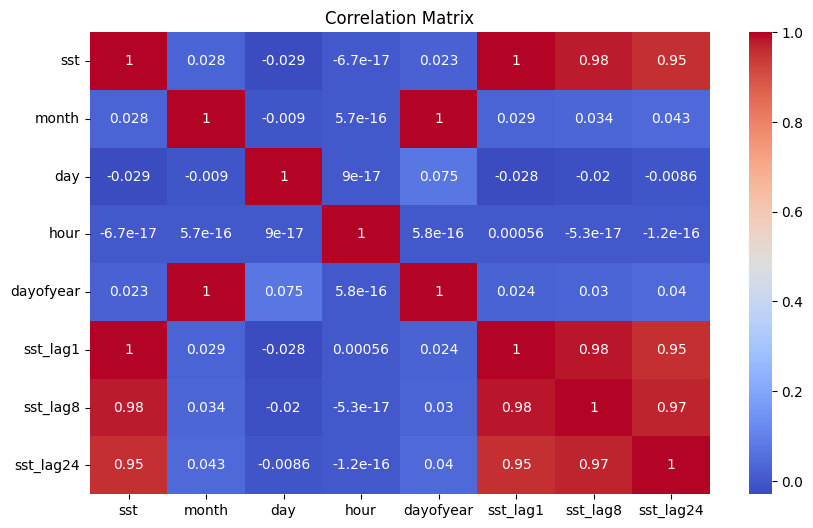

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df2018[
    [
        'sst',
        'month',
        'day',
        'hour',
        'dayofyear',
        'sst_lag1',
        'sst_lag8',
        'sst_lag24'
    ]
].corr()

print(corr['sst'].sort_values(
    ascending=False
))

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Correlation Matrix"
)

plt.show()

     Feature  Importance
4   sst_lag1    0.994975
6  sst_lag24    0.001320
5   sst_lag8    0.000943
2       hour    0.000926
1        day    0.000920
3  dayofyear    0.000773
0      month    0.000143


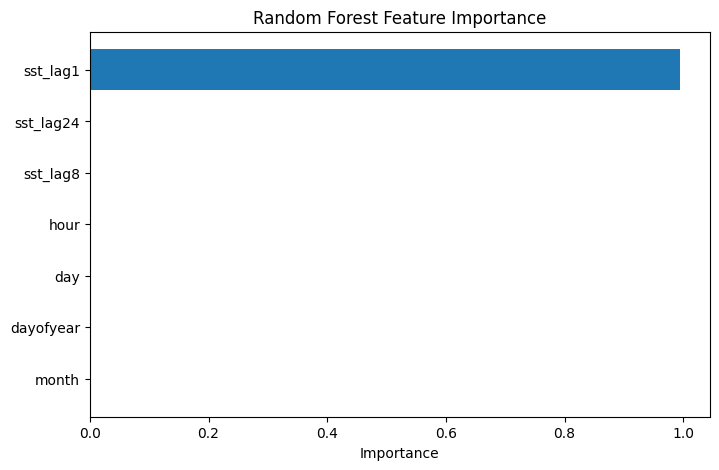

     Feature  Percentage
4   sst_lag1   99.497473
6  sst_lag24    0.131998
5   sst_lag8    0.094320
2       hour    0.092623
1        day    0.091963
3  dayofyear    0.077297
0      month    0.014327


In [9]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

X = df2018[
    [
        'month',
        'day',
        'hour',
        'dayofyear',
        'sst_lag1',
        'sst_lag8',
        'sst_lag24'
    ]
]

y = df2018['sst']

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X,y)

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

importance["Percentage"] = (

    importance["Importance"]
    /
    importance["Importance"].sum()

) * 100

print(
    importance[
        ["Feature","Percentage"]
    ]
)



In [10]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

all_importances = []

for task in tasks:

    X = task[features]
    y = task['sst']

    rf = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    rf.fit(X, y)

    all_importances.append(
        rf.feature_importances_
    )

avg_importance = np.mean(
    all_importances,
    axis=0
)

importance_df = pd.DataFrame({

    "Feature": features,

    "Importance": avg_importance

})

importance_df["Percentage"] = (

    importance_df["Importance"]
    /
    importance_df["Importance"].sum()

) * 100

importance_df = importance_df.sort_values(
    by="Percentage",
    ascending=False
)

print(importance_df)

     Feature  Importance  Percentage
4   sst_lag1    0.993841   99.384053
6  sst_lag24    0.001622    0.162189
3  dayofyear    0.001273    0.127289
1        day    0.001180    0.118000
2       hour    0.000995    0.099501
5   sst_lag8    0.000935    0.093480
0      month    0.000155    0.015488


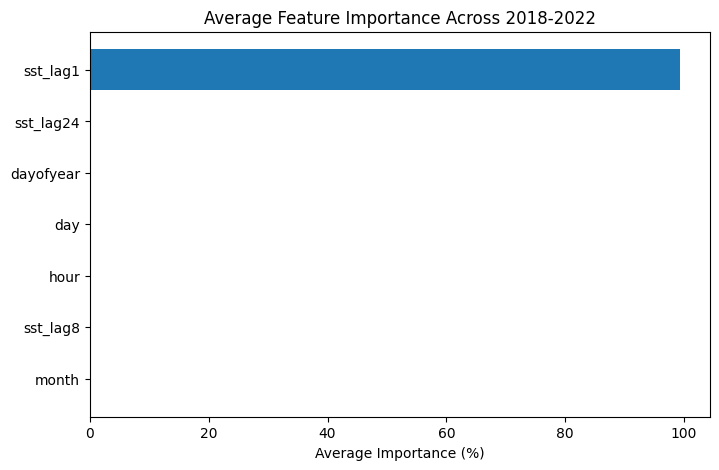

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    importance_df["Feature"],
    importance_df["Percentage"]
)

plt.xlabel("Average Importance (%)")
plt.title(
    "Average Feature Importance Across 2018-2022"
)

plt.gca().invert_yaxis()

plt.show()